# Part II: Exploratory Data Analysis (EDA)

## Basic settings

In [180]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [181]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.options.display.max_rows = 50
pd.options.display.max_columns = None
sns.set_theme(style="whitegrid")

In [182]:
DATA_DIR = "../data"
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

save_figure = True

## Load preprocessed data

All four tables, not just sales and weather. Holiday and promotion carry the
external factors this study is built around, so leaving them out of the EDA leaves
the feature engineering that follows unmotivated.

In [183]:
df_sales = pd.read_csv(
    os.path.join(DATA_DIR, "sales_data_preprocessed.csv"), parse_dates=["date"]
)
df_weather = pd.read_csv(
    os.path.join(DATA_DIR, "weather_preprocessed.csv"), parse_dates=["date"]
)
df_holiday = pd.read_csv(
    os.path.join(DATA_DIR, "holiday_preprocessed.csv"), parse_dates=["date"]
)
df_promotion = pd.read_csv(
    os.path.join(DATA_DIR, "promotion_preprocessed.csv"),
    parse_dates=["start_date", "end_date"],
)

for name, frame in [("sales", df_sales), ("weather", df_weather),
                    ("holiday", df_holiday), ("promotion", df_promotion)]:
    print(f"{name:10s} {len(frame):>8,} rows x {frame.shape[1]:>2} cols")

sales       394,560 rows x 14 cols
weather       4,384 rows x 10 cols
holiday       4,384 rows x  9 cols
promotion     7,177 rows x 12 cols


In [184]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 394560 entries, 0 to 394559
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          394560 non-null  datetime64[ns]
 1   province      394560 non-null  object        
 2   store_id      394560 non-null  int64         
 3   store_name    394560 non-null  object        
 4   category      394560 non-null  object        
 5   item_id       394560 non-null  int64         
 6   item_name     394560 non-null  object        
 7   price         394560 non-null  float64       
 8   base_price    394560 non-null  float64       
 9   is_promotion  394560 non-null  bool          
 10  promo_id      394560 non-null  int64         
 11  sales         394560 non-null  float64       
 12  day_of_week   394560 non-null  int64         
 13  discount_pct  394560 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(4), int64(4), object(4)
memor

In [185]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          4384 non-null   datetime64[ns]
 1   city          4384 non-null   object        
 2   province      4384 non-null   object        
 3   temperature   4384 non-null   float64       
 4   humidity      4384 non-null   float64       
 5   season        4384 non-null   object        
 6   month         4384 non-null   int64         
 7   temp_norm     4384 non-null   float64       
 8   temp_anomaly  4384 non-null   float64       
 9   is_humid      4384 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 342.6+ KB


In [186]:
df_holiday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                4384 non-null   datetime64[ns]
 1   province            4384 non-null   object        
 2   day_of_week         4384 non-null   object        
 3   is_weekend          4384 non-null   bool          
 4   is_public_holiday   4384 non-null   bool          
 5   holiday_name        126 non-null    object        
 6   is_school_holiday   4384 non-null   bool          
 7   days_to_holiday     4384 non-null   int64         
 8   days_since_holiday  4384 non-null   int64         
dtypes: bool(3), datetime64[ns](1), int64(2), object(3)
memory usage: 218.5+ KB


## Perform EDA

### 1. Dataset overview

In [187]:
print("BASIC STATISTICAL SUMMARY:\n")
print("Sales:")
print(df_sales["sales"].describe().round(2))
print("\nWeather:")
print(df_weather[["temperature", "humidity", "temp_anomaly"]].describe().round(2))

print(f"\nDate range: {df_sales['date'].min().date()} to {df_sales['date'].max().date()}")
print(f"Days: {df_sales['date'].nunique():,}")
print(f"Stores: {df_sales['store_id'].nunique()}   Items: {df_sales['item_id'].nunique()}")
print(f"Series (store x item): {df_sales.groupby(['store_id','item_id']).ngroups:,}")
print(f"Categories: {sorted(df_sales['category'].unique())}")
print(f"Provinces: {sorted(df_sales['province'].unique())}")
print(f"Promotion days: {df_sales['is_promotion'].mean():.1%}")

BASIC STATISTICAL SUMMARY:

Sales:
count    394560.00
mean         22.24
std          19.53
min           0.00
25%           9.00
50%          16.00
75%          28.00
max         343.00
Name: sales, dtype: float64

Weather:
       temperature  humidity  temp_anomaly
count      4384.00   4384.00       4384.00
mean         18.12     64.45          0.00
std           5.57      9.75          3.55
min          -1.00     31.30        -15.20
25%          14.40     58.60         -2.27
50%          18.30     65.30         -0.00
75%          22.30     71.20          2.33
max          34.10     96.30         13.88

Date range: 2023-01-01 to 2025-12-31
Days: 1,096
Stores: 12   Items: 30
Series (store x item): 360
Categories: ['Beverages', 'Dairy & Frozen', 'Household', 'Snacks', 'Staples']
Provinces: ['New South Wales', 'Queensland', 'South Australia', 'Victoria']
Promotion days: 17.0%


### 2. Series-level characteristics

The most useful table here, and the one most EDA skips. The comparison between
global ML and local statistical models turns on *which* series each family handles
well, so the segmentation variables need establishing before any modelling.

In [188]:
series_stats = (
    df_sales.groupby(["store_id", "item_id", "item_name", "category"])["sales"]
    .agg(mean_sales="mean", std_sales="std", zero_share=lambda x: (x == 0).mean())
    .reset_index()
)
series_stats["cv"] = series_stats["std_sales"] / series_stats["mean_sales"]

display(series_stats[["mean_sales", "std_sales", "cv", "zero_share"]].describe().round(3))

item_vol = df_sales.groupby("item_name")["sales"].mean().sort_values(ascending=False)
print("\nHighest and lowest volume items:")
display(pd.concat([item_vol.head(5), item_vol.tail(5)]).round(2))
print(f"ratio highest:lowest = {item_vol.max() / item_vol.min():.1f}x")

,mean_sales,std_sales,cv,zero_share
count,360.000,360.000,360.000,360.000
mean,22.239,8.874,0.423,0.003
std,16.345,6.029,0.064,0.007
min,3.442,2.279,0.294,0.000
25%,10.920,4.840,0.388,0.000
50%,16.201,6.526,0.412,0.001
75%,27.720,10.870,0.442,0.002
max,82.484,35.759,0.668,0.067



Highest and lowest volume items:


item_name
Full Cream Milk 2L        63.58
Cola Soft Drink 1.25L     59.67
Potato Chips 175g         50.54
White Bread Loaf          48.42
Spring Water 6L           39.85
White Sugar 1kg            9.17
Sunscreen SPF50+ 200ml     8.57
Plain Flour 1kg            8.13
Insect Repellent 150ml     6.05
Firelighters 24pk          4.62
Name: sales, dtype: float64

ratio highest:lowest = 13.7x


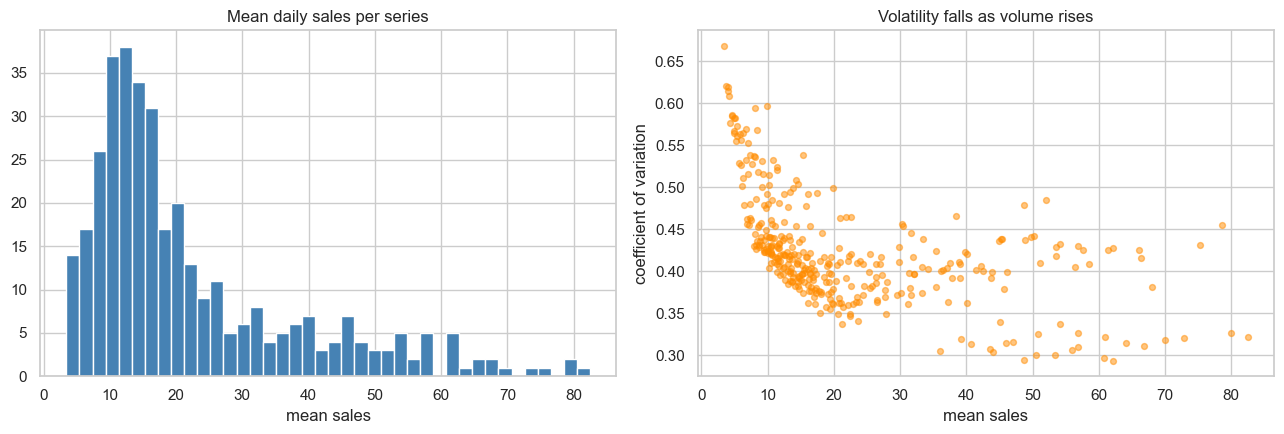

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(series_stats["mean_sales"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Mean daily sales per series")
axes[0].set_xlabel("mean sales")
axes[1].scatter(series_stats["mean_sales"], series_stats["cv"], alpha=0.5, s=18,
                color="darkorange")
axes[1].set_title("Volatility falls as volume rises")
axes[1].set_xlabel("mean sales")
axes[1].set_ylabel("coefficient of variation")
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "series_characteristics.png"), dpi=120)
plt.show()

### 3. Sales over time

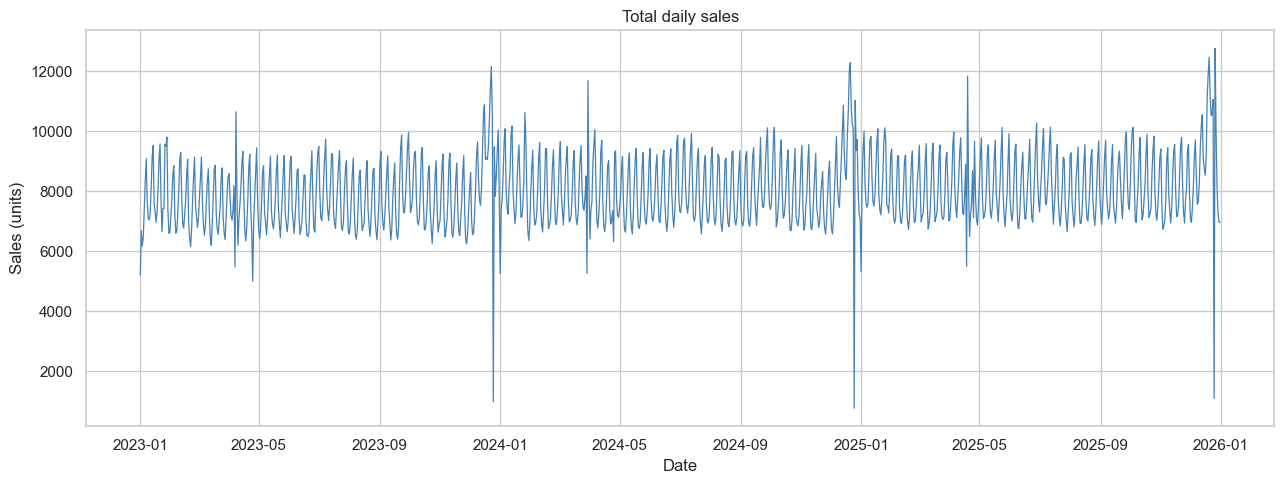

In [190]:
plt.figure(figsize=(13, 5))
daily = df_sales.groupby("date")["sales"].sum().reset_index()
plt.plot(daily["date"], daily["sales"], linewidth=0.9, color="steelblue")
plt.title("Total daily sales")
plt.xlabel("Date")
plt.ylabel("Sales (units)")
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "daily_sales_trend.png"), dpi=120)
plt.show()



### 4. Seasonality - Southern Hemisphere

Australian seasons are inverted: January is midsummer, July is midwinter. Any
seasonal plot or feature carried over from a Northern Hemisphere study reads
backwards.

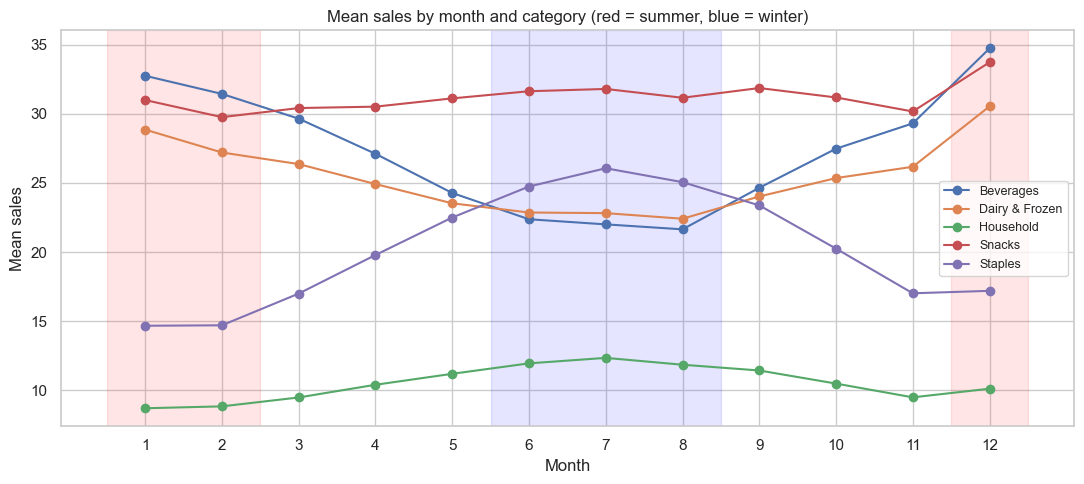

In [191]:
df_sales["month"] = df_sales["date"].dt.month
df_sales["year"] = df_sales["date"].dt.year
monthly = df_sales.groupby(["category", "month"])["sales"].mean().unstack(0)

plt.figure(figsize=(11, 5))
for cat in monthly.columns:
    plt.plot(monthly.index, monthly[cat], marker="o", label=cat)
plt.axvspan(0.5, 2.5, alpha=0.10, color="red")
plt.axvspan(11.5, 12.5, alpha=0.10, color="red")
plt.axvspan(5.5, 8.5, alpha=0.10, color="blue")
plt.xticks(range(1, 13))
plt.title("Mean sales by month and category (red = summer, blue = winter)")
plt.xlabel("Month")
plt.ylabel("Mean sales")
plt.legend(fontsize=9)
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "seasonality_by_category.png"), dpi=120)
plt.show()

In [192]:
summer_winter = (
    df_sales[df_sales["month"].isin([1, 7])]
    .groupby(["item_name", "month"])["sales"].mean().unstack()
)
summer_winter.columns = ["January", "July"]
summer_winter["jan_over_jul"] = (summer_winter["January"] / summer_winter["July"]).round(2)

print("Strongest summer items:")
display(summer_winter.nlargest(5, "jan_over_jul").round(2))
print("Strongest winter items:")
display(summer_winter.nsmallest(5, "jan_over_jul").round(2))

Strongest summer items:


,January,July,jan_over_jul
item_name,,,
Full Cream Milk 2L,84.97,45.35,1.87
Greek Yoghurt 1kg,31.35,17.20,1.82
Muesli Bars 6pk,27.55,15.31,1.80
Sunscreen SPF50+ 200ml,10.94,6.16,1.78
Cola Soft Drink 1.25L,75.58,42.90,1.76


Strongest winter items:


,January,July,jan_over_jul
item_name,,,
Frozen Mixed Vegetables 1kg,9.25,17.16,0.54
Plain Flour 1kg,5.67,10.42,0.54
Laundry Liquid 2L,7.90,14.40,0.55
Toilet Paper 12pk,13.01,23.51,0.55
Dried Pasta 500g,15.59,27.88,0.56


### 5. Day of week

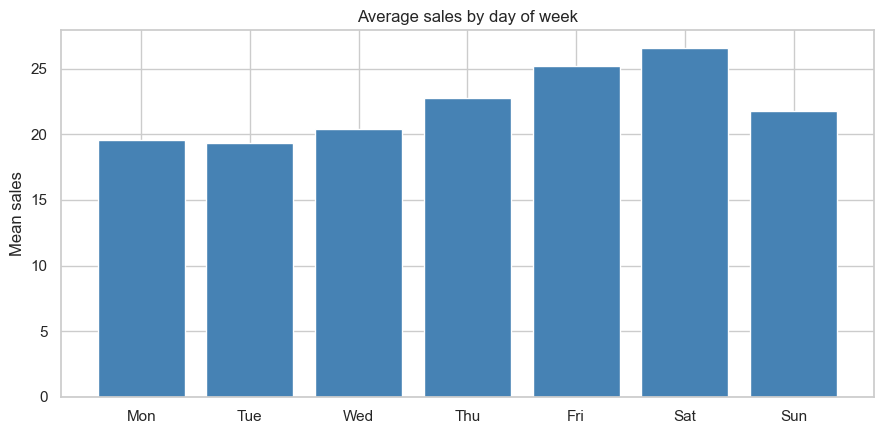

In [193]:
plt.figure(figsize=(9, 4.5))
df_sales["day_of_week"] = df_sales["date"].dt.dayofweek
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_day = df_sales.groupby("day_of_week")["sales"].mean().reindex(range(7))
plt.bar(day_names, by_day, color="steelblue")
plt.title("Average sales by day of week")
plt.ylabel("Mean sales")
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "sales_by_day.png"), dpi=120)
plt.show()

### 6. Category and province

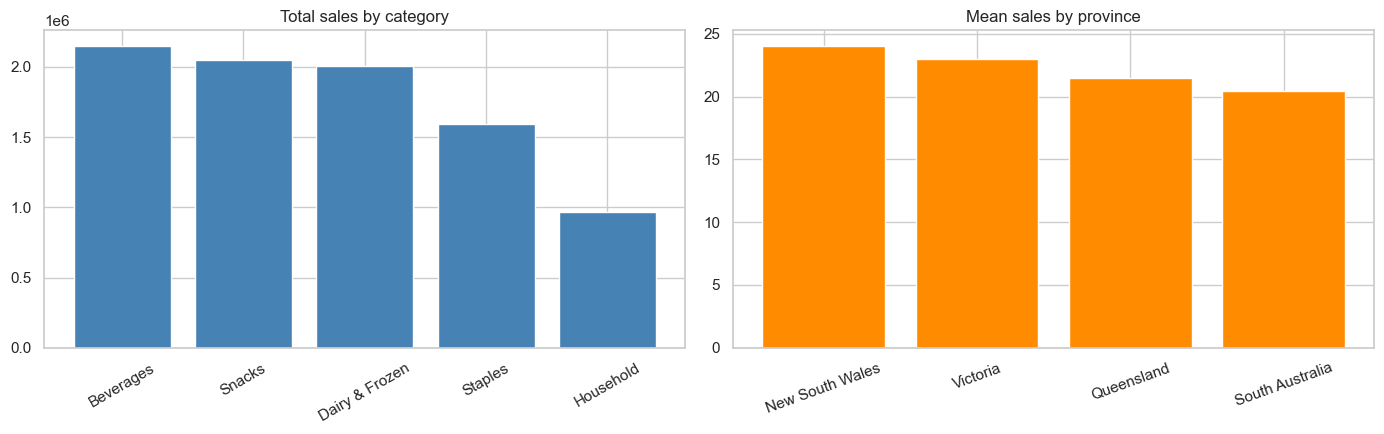

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
cat = df_sales.groupby("category")["sales"].sum().sort_values(ascending=False)
axes[0].bar(cat.index, cat.values, color="steelblue")
axes[0].set_title("Total sales by category")
axes[0].tick_params(axis="x", rotation=30)
prov = df_sales.groupby("province")["sales"].mean().sort_values(ascending=False)
axes[1].bar(prov.index, prov.values, color="darkorange")
axes[1].set_title("Mean sales by province")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "sales_by_category_province.png"), dpi=120)
plt.show()

### 7. Weather - and why aggregating hides the effect

The obvious plot is total sales against temperature. It is close to useless here,
for two reasons.

**Raw temperature is not comparable across cities.** 25 C is mild in Brisbane and
hot in Melbourne. Use `temp_anomaly`, the deviation from that city's own norm for
that month.

**Aggregating across items cancels the effect.** Ice cream rises with temperature
and coffee falls, so summing them leaves almost nothing. The weather signal is
item-level and has to be looked at item-level.

In [195]:
sales_weather = df_sales.merge(
    df_weather[["date", "province", "temperature", "temp_anomaly", "humidity", "is_humid"]],
    on=["date", "province"], how="left",
)
assert sales_weather["temperature"].isna().sum() == 0, "weather join failed"

agg = (
    sales_weather.groupby(["date", "province"])
    .agg(sales=("sales", "sum"), temp_anomaly=("temp_anomaly", "first"))
    .reset_index()
)
print(f"correlation, aggregated over all items: {agg['sales'].corr(agg['temp_anomaly']):+.4f}")

item_corr = (
    sales_weather.groupby("item_name")
    .apply(lambda g: g["sales"].corr(g["temp_anomaly"]))
    .sort_values()
)
print(f"item-level correlations range {item_corr.min():+.3f} to {item_corr.max():+.3f}")

correlation, aggregated over all items: +0.1716
item-level correlations range -0.248 to +0.307


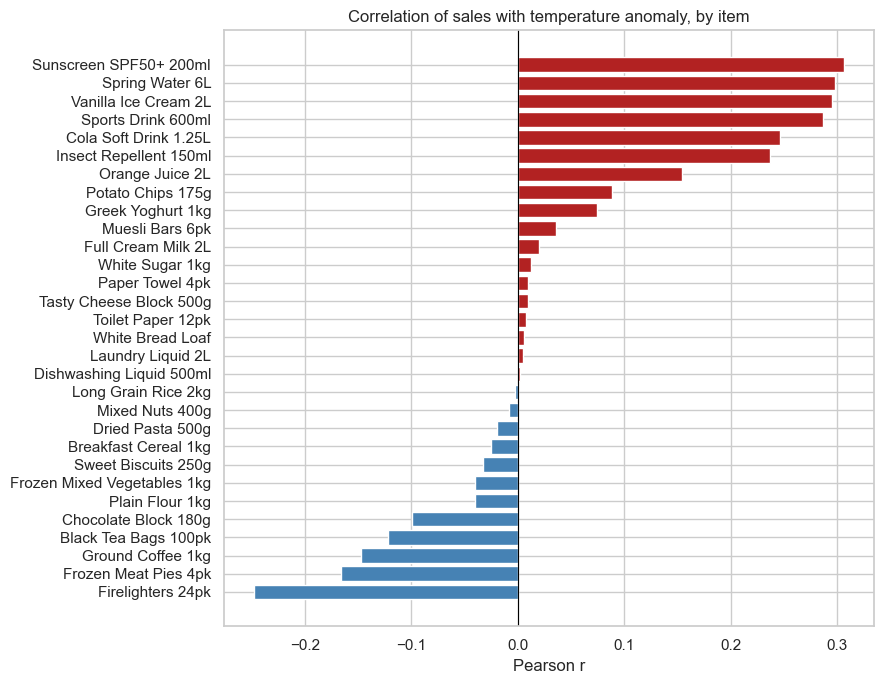

In [196]:
plt.figure(figsize=(9, 7))
colors = ["firebrick" if v > 0 else "steelblue" for v in item_corr.values]
plt.barh(item_corr.index, item_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of sales with temperature anomaly, by item")
plt.xlabel("Pearson r")
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "temp_correlation_by_item.png"), dpi=120)
plt.show()

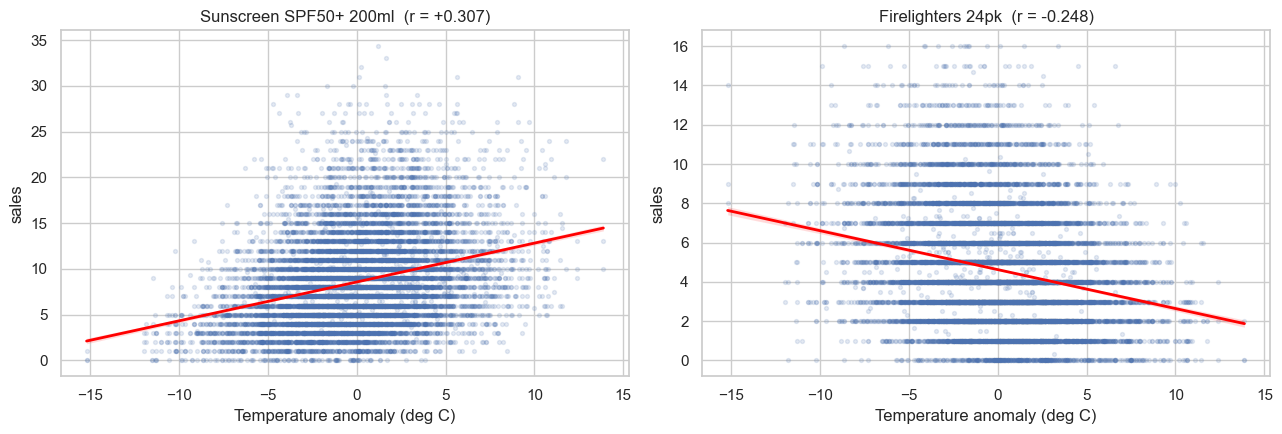

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, item in zip(axes, [item_corr.index[-1], item_corr.index[0]]):
    sub = sales_weather[sales_weather["item_name"] == item]
    sns.regplot(data=sub, x="temp_anomaly", y="sales", ax=ax,
                scatter_kws={"alpha": 0.15, "s": 8},
                line_kws={"color": "red", "linewidth": 2})
    ax.set_title(f"{item}  (r = {item_corr[item]:+.3f})")
    ax.set_xlabel("Temperature anomaly (deg C)")
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "sales_vs_temp_anomaly.png"), dpi=120)
plt.show()

### 8. Promotions

In [198]:
promo_lift = df_sales.groupby(["item_name", "is_promotion"])["sales"].mean().unstack()
promo_lift.columns = ["off_promo", "on_promo"]
promo_lift["lift"] = (promo_lift["on_promo"] / promo_lift["off_promo"]).round(2)

print(f"Promotion coverage: {df_sales['is_promotion'].mean():.1%} of store-item-days")
print(f"Mean lift {promo_lift['lift'].mean():.2f}x, "
      f"range {promo_lift['lift'].min():.2f}x to {promo_lift['lift'].max():.2f}x\n")
display(pd.concat([promo_lift.nlargest(5, "lift"),
                   promo_lift.nsmallest(5, "lift")]).round(2))

Promotion coverage: 17.0% of store-item-days
Mean lift 1.40x, range 1.23x to 1.60x



,off_promo,on_promo,lift
item_name,,,
Potato Chips 175g,43.64,69.78,1.60
Cola Soft Drink 1.25L,52.50,82.03,1.56
Chocolate Block 180g,29.74,45.02,1.51
Sports Drink 600ml,10.20,15.35,1.51
Vanilla Ice Cream 2L,16.00,24.03,1.50
White Bread Loaf,47.49,58.60,1.23
Full Cream Milk 2L,62.50,79.27,1.27
Long Grain Rice 2kg,15.87,20.30,1.28
White Sugar 1kg,8.95,11.57,1.29


,rows,mean_lift
promo_type,,
Catalogue,33610,1.58
Clearance,2606,1.70
In-Store Display,30938,1.24


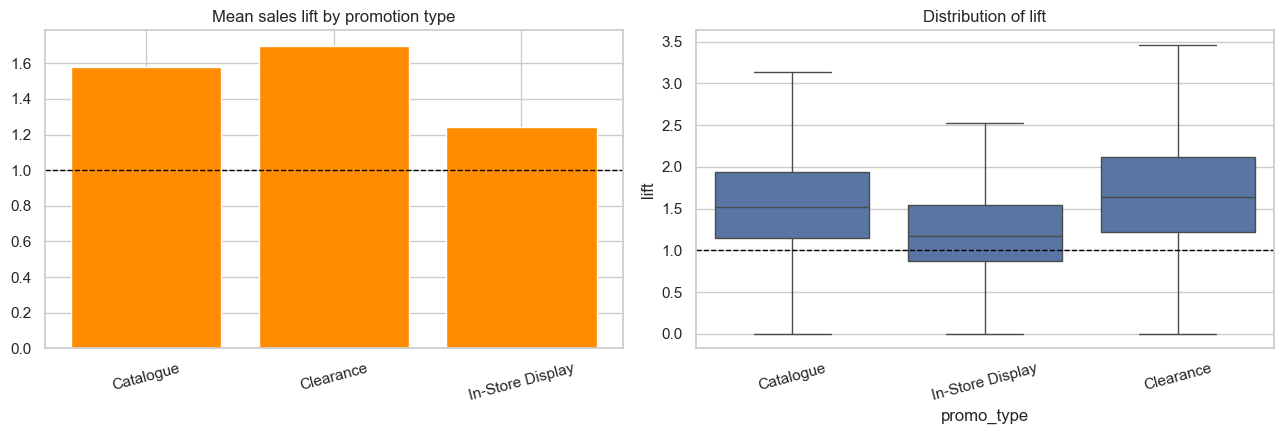

In [199]:
sales_promo = df_sales.merge(df_promotion[["promo_id", "promo_type"]],
                             on="promo_id", how="left")
baseline = df_sales[df_sales["is_promotion"] == 0].groupby("item_id")["sales"].mean()
on = sales_promo[sales_promo["is_promotion"] == 1].copy()
on["baseline"] = on["item_id"].map(baseline)
on["lift"] = on["sales"] / on["baseline"]

by_type = on.groupby("promo_type").agg(rows=("lift", "size"),
                                       mean_lift=("lift", "mean")).round(2)
display(by_type)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(by_type.index, by_type["mean_lift"], color="darkorange")
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Mean sales lift by promotion type")
axes[0].tick_params(axis="x", rotation=15)
sns.boxplot(data=on, x="promo_type", y="lift", ax=axes[1], showfliers=False)
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Distribution of lift")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "promo_lift_by_type.png"), dpi=120)
plt.show()

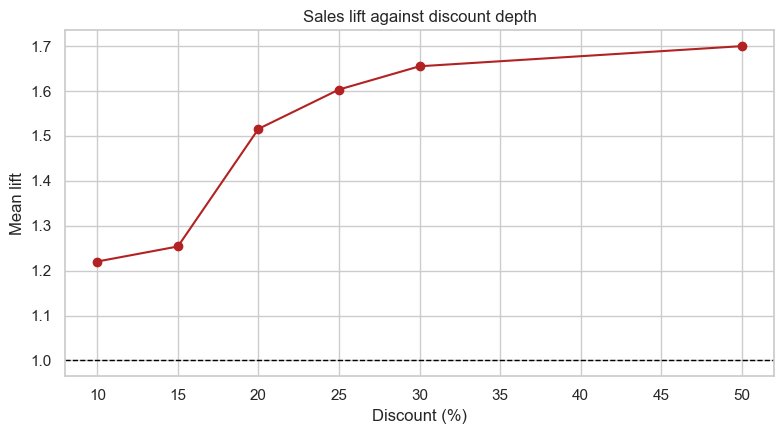

In [200]:
depth = on.groupby(on["discount_pct"].round(0))["lift"].mean()
plt.figure(figsize=(8, 4.5))
plt.plot(depth.index, depth.values, marker="o", color="firebrick")
plt.axhline(1.0, color="black", linestyle="--", linewidth=1)
plt.title("Sales lift against discount depth")
plt.xlabel("Discount (%)")
plt.ylabel("Mean lift")
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "lift_vs_discount.png"), dpi=120)
plt.show()

### 9. Holidays

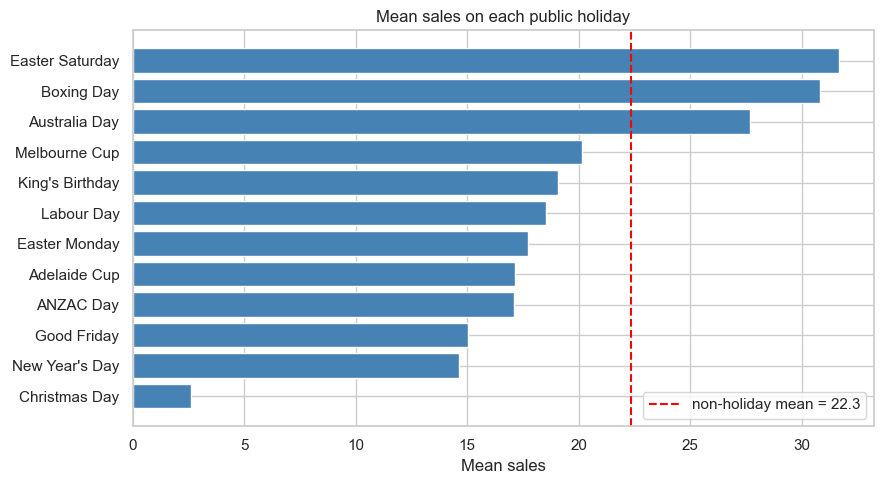

In [201]:
hol_cols = ["date", "province", "is_public_holiday", "holiday_name",
            "is_school_holiday", "days_to_holiday"]
sales_hol = df_sales.merge(df_holiday[hol_cols], on=["date", "province"], how="left")
assert sales_hol["is_public_holiday"].isna().sum() == 0, "holiday join failed"

named = (sales_hol[sales_hol["is_public_holiday"] == 1]
         .groupby("holiday_name")["sales"].mean().sort_values())
normal = sales_hol[sales_hol["is_public_holiday"] == 0]["sales"].mean()

plt.figure(figsize=(9, 5))
plt.barh(named.index, named.values, color="steelblue")
plt.axvline(normal, color="red", linestyle="--", linewidth=1.5,
            label=f"non-holiday mean = {normal:.1f}")
plt.title("Mean sales on each public holiday")
plt.xlabel("Mean sales")
plt.legend()
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "sales_by_holiday.png"), dpi=120)
plt.show()

### 10. The state-holiday natural experiment

Labour Day is March in Victoria, May in Queensland, October in NSW and SA.
King's Birthday is June in three states and October in Queensland. Melbourne Cup is
Victoria only.

The same calendar date is therefore a public holiday in one state and an ordinary
trading day in another, with weather and day of week held constant. That is a clean
identification strategy and deserves its own subsection in the final report.

In [202]:
by_date = df_holiday.groupby("date")["is_public_holiday"].agg(["sum", "size"])
split_dates = by_date[(by_date["sum"] > 0) & (by_date["sum"] < by_date["size"])].index
print(f"Dates that are a holiday in some states but not all: {len(split_dates)}")

split = sales_hol[sales_hol["date"].isin(split_dates)]
comparison = split.groupby("is_public_holiday")["sales"].agg(
    mean_sales="mean", n="size").round(2)
comparison.index = ["ordinary trading day", "public holiday"]
display(comparison)

ratio = (comparison.loc["public holiday", "mean_sales"]
         / comparison.loc["ordinary trading day", "mean_sales"])
print(f"\nSame dates, different states: holiday effect = {ratio:.3f}x")

Dates that are a holiday in some states but not all: 15


,mean_sales,n
ordinary trading day,19.28,2700
public holiday,18.76,2700



Same dates, different states: holiday effect = 0.973x


### 11. Correlation overview

Empty DataFrame
Columns: [date, province, store_id, store_name, category, item_id, item_name, price, base_price, is_promotion, promo_id, sales, day_of_week, discount_pct, month, year, temperature, temp_anomaly, humidity, is_humid, is_public_holiday, is_school_holiday]
Index: []


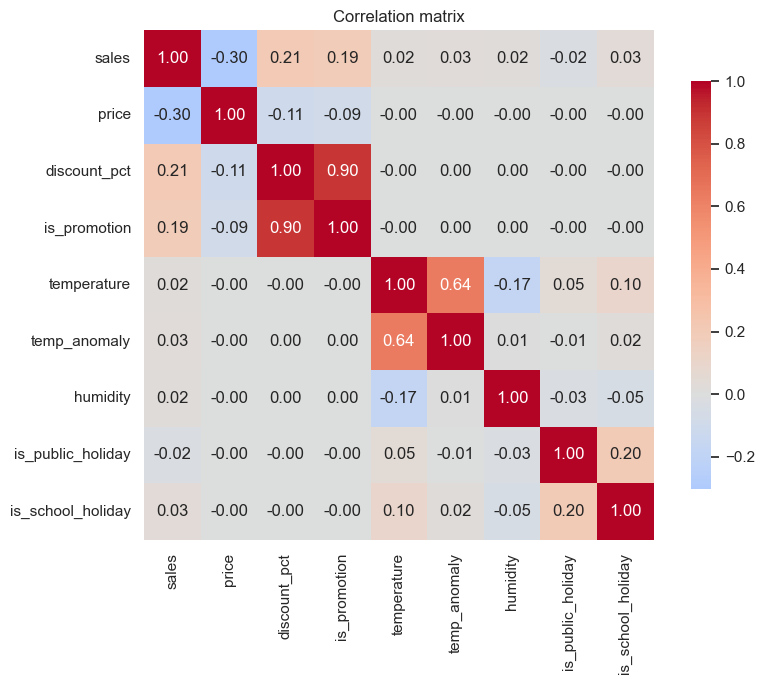

In [ ]:
num = sales_weather.merge(
    df_holiday[["date", "province", "is_public_holiday", "is_school_holiday"]],
    on=["date", "province"], how="left",
)
cols = ["sales", "price", "discount_pct", "is_promotion", "temperature",
        "temp_anomaly", "humidity", "is_public_holiday", "is_school_holiday"]
plt.figure(figsize=(9, 7))
#print(num[(num['is_promotion'] == 1) & (num['discount_pct'] == 0)])
sns.heatmap(num[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix")
plt.tight_layout()
if save_figure:
    plt.savefig(os.path.join(FIGURES_DIR, "correlation_matrix.png"), dpi=120)
plt.show()

### EDA summary

Points to carry into feature engineering:

1. **Volume spans a wide range across items**, so a global model needs either a
   target transform or per-series normalisation.
2. **Seasonality is Southern Hemisphere.** Summer-peaking and winter-peaking items
   move in opposite directions and partly cancel in any aggregate.
3. **Weather effects are item-level and sign-flipping.** Use `temp_anomaly`, and
   never judge the weather signal on aggregated sales.
4. **Promotion is the strongest single driver**, and lift varies by promotion type,
   so `promo_type` and `discount_pct` both belong in the feature set.
5. **Holiday effects vary by state**; keep the province dimension.